In [35]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [36]:


columns = [
    'Intern_ID',
    'Task_Completion',
    'Consistency',
    'Engagement',
    'Performance'
]

print("✅ Dataset structure defined!")
print("Columns:", columns)

✅ Dataset structure defined!
Columns: ['Intern_ID', 'Task_Completion', 'Consistency', 'Engagement', 'Performance']


In [37]:


# ============================================
# CELL 3: CREATE SAMPLE DATASET (HIDDEN DATA)
# ============================================

import random

rows = []

for i in range(1, 11):
    task = random.randint(70, 95)
    consistency = random.randint(65, 90)
    engagement = random.randint(70, 96)

    performance = int((task + consistency + engagement) / 3)

    rows.append([
        f"INT{i:03}",
        task,
        consistency,
        engagement,
        performance
    ])

df = pd.DataFrame(rows, columns=[
    'Intern_ID',
    'Task_Completion',
    'Consistency',
    'Engagement',
    'Performance'
])

df.to_csv('intern_data.csv', index=False)

print("✅ Dataset created successfully!")

✅ Dataset created successfully!


In [38]:


df = pd.read_csv('intern_data.csv')

print("✅ CSV file imported successfully!")
print(f"Shape: {df.shape}")
print(df)

✅ CSV file imported successfully!
Shape: (10, 5)
  Intern_ID  Task_Completion  Consistency  Engagement  Performance
0    INT001               88           77          93           86
1    INT002               78           66          88           77
2    INT003               85           65          75           75
3    INT004               95           88          92           91
4    INT005               88           84          85           85
5    INT006               78           67          70           71
6    INT007               76           65          89           76
7    INT008               84           75          79           79
8    INT009               79           87          77           81
9    INT010               78           86          76           80


In [39]:


print("📊 Dataset Info:")
print(df.info())

print("\n📈 Statistical Summary:")
print(df.describe())

print("\n🔍 Null Values Check:")
print(df.isnull().sum())

📊 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Intern_ID        10 non-null     str  
 1   Task_Completion  10 non-null     int64
 2   Consistency      10 non-null     int64
 3   Engagement       10 non-null     int64
 4   Performance      10 non-null     int64
dtypes: int64(4), str(1)
memory usage: 532.0 bytes
None

📈 Statistical Summary:
       Task_Completion  Consistency  Engagement  Performance
count        10.000000    10.000000   10.000000    10.000000
mean         82.900000    76.000000   82.400000    80.100000
std           6.136412     9.741093    8.002777     5.915141
min          76.000000    65.000000   70.000000    71.000000
25%          78.000000    66.250000   76.250000    76.250000
50%          81.500000    76.000000   82.000000    79.500000
75%          87.250000    85.500000   88.750000    84.000000
max          95.00

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_6120\3238231467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Intern_ID', y='Performance', palette='viridis')


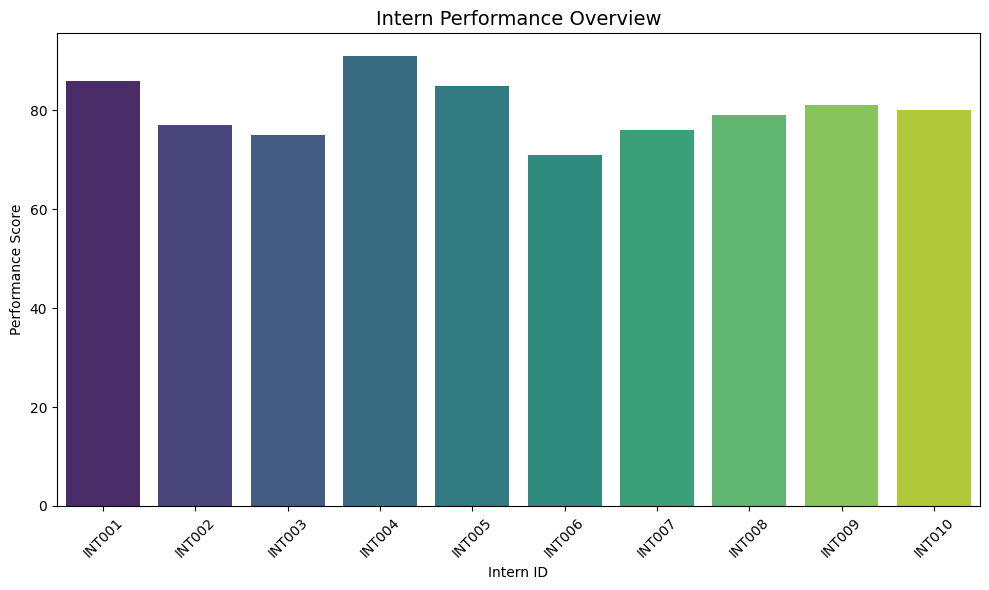

✅ Visualization complete!


In [41]:
# ============================================
# CELL 5: VISUALIZATION
# ============================================

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Intern_ID', y='Performance', palette='viridis')
plt.title('Intern Performance Overview', fontsize=14)
plt.xlabel('Intern ID')
plt.ylabel('Performance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

In [43]:
# ============================================
# CELL 6: SAVE COMPLETE OUTPUT AS CSV
# ============================================

import os
import pandas as pd
import io

# 1. Capture Dataset Info
buffer = io.StringIO()
df.info(buf=buffer)
info_text = buffer.getvalue()

# Convert info to dataframe
info_lines = []
for line in info_text.split('\n'):
    if line.strip():
        info_lines.append([line])
info_df = pd.DataFrame(info_lines, columns=['Dataset_Info'])

# 2. Statistical Summary
stats_df = df.describe().reset_index()
stats_df.rename(columns={'index': 'Metric'}, inplace=True)

# 3. Null Values
null_df = pd.DataFrame({
    'Column': df.isnull().sum().index,
    'Null_Count': df.isnull().sum().values
})

# 4. Save ALL to one CSV
with open('dataset_output.csv', 'w', encoding='utf-8') as f:

    f.write("=== DATASET INFO ===\n")
    info_df.to_csv(f, index=False)

    f.write("\n=== FULL DATASET ===\n")
    df.to_csv(f, index=False)

    f.write("\n=== STATISTICAL SUMMARY ===\n")
    stats_df.to_csv(f, index=False)

    f.write("\n=== NULL VALUES CHECK ===\n")
    null_df.to_csv(f, index=False)

print("✅ dataset_output.csv saved successfully!")
print(f"📁 Location: {os.getcwd()}")

✅ dataset_output.csv saved successfully!
📁 Location: c:\Users\ELCOT\Desktop\intern-performance-prediction
